# Micro-Project 2: Locating the Income Disparity by Sex
### UCI Adult / Census Income Dataset (1994 US Census)
#### Janna Hoyne

**Problem statement.** Aggregate comparisons of earnings by sex are frequently
adjusted for occupation and hours worked, and the residual gap is reported as
the disparity. This treats occupational placement and hours capacity as neutral
characteristics. If access to higher-paying occupations and the ability to work
long hours are themselves unequally distributed, adjusting for them removes the
mechanism from the measurement rather than explaining it. This project measures
where the income disparity is located across strata rather than adjusting it away.

**Original hypothesis (H1).** The income disparity between men and women is not
uniform and does not resolve under matching.
- the gap persists within matched strata — at equal education and equal hours worked, women remain less likely to earn above $50K
- occupational composition differs substantially by sex, making occupational sorting a component of the disparity rather than an explanation of it

**Scope.** This project terminates at Step 2 (Prepare) of the data science
process. Deliverables are a documented, analysis-ready dataset and descriptive
findings — no models or significance testing. Stratified comparison is used in
place of statistical adjustment: group rates are computed within matched cells
rather than estimated from a model.

**Data.** 32,561 records drawn from the 1994 US Census. Fifteen variables:
demographic, educational, occupational, and a binary income indicator
(≤$50K / >$50K). The data is a single cross-section, so
change over time is outside the scope of this analysis.

**Terminology.** The dataset records sex as a binary variable with two
categories, and this analysis uses that coding as given. Income is recorded
only as a binary threshold, so all results describe the probability of exceeding
$50K rather than earnings amounts.

## Acquire

### Environment

Only NumPy, pandas, and the Python standard library are used. Library versions
are printed so results can be reproduced against the same environment.

In [1]:
import numpy as np
import pandas as pd
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 120)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.3 | numpy 2.3.5


In [2]:
import os

# The file ships under either name depending on where it was downloaded.
PATH = next(p for p in ['adult_income.csv', 'adult income.csv']
            if os.path.exists(p))
df = pd.read_csv(PATH)

print("Loaded:", PATH)
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes.to_string())

Loaded: adult income.csv
Shape: (32561, 15)

Dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object


In [3]:
# pandas found no missing values, but that only means no empty cells.
# This dataset encodes non-response as the literal string '?', which
# pandas reads as a valid category.
print("Standard missing (NaN):", df.isna().sum().sum())

# Count '?' per column. .astype(str).str.strip() guards against any
# stray whitespace around the marker.
q = (df.astype(str).apply(lambda s: s.str.strip()) == '?').sum()
print("\nColumns containing '?':")
print(q[q > 0].to_string())

Standard missing (NaN): 0

Columns containing '?':
workclass         1836
occupation        1843
native-country     583


In [4]:
# Convert '?' to NaN so pandas can work with it properly.
df = df.replace('?', np.nan)

print("Missing after recode:")
print(df.isna().sum()[lambda s: s > 0].to_string())

# workclass and occupation are within 7 cases of each other - check
# whether they fail on the same rows.
both = df['workclass'].isna() & df['occupation'].isna()
wc_only = df['workclass'].isna() & df['occupation'].notna()
oc_only = df['occupation'].isna() & df['workclass'].notna()

print(f"\nMissing both        : {both.sum()}")
print(f"Missing workclass only : {wc_only.sum()}")
print(f"Missing occupation only: {oc_only.sum()}")

Missing after recode:
workclass         1836
occupation        1843
native-country     583

Missing both        : 1836
Missing workclass only : 0
Missing occupation only: 7


In [5]:
# The 7 cases with occupation missing but workclass present.
odd = df[df['occupation'].isna() & df['workclass'].notna()]
print(odd[['age', 'workclass', 'occupation', 'hours-per-week', 'income']].to_string())

       age     workclass occupation  hours-per-week income
5361    18  Never-worked        NaN              40  <=50K
10845   23  Never-worked        NaN              35  <=50K
14772   17  Never-worked        NaN              30  <=50K
20337   18  Never-worked        NaN              10  <=50K
23232   20  Never-worked        NaN              40  <=50K
32304   30  Never-worked        NaN              40  <=50K
32314   18  Never-worked        NaN               4  <=50K


In [6]:
# Are the 1,836 systematically different, or effectively random?
df['emp_missing'] = df['workclass'].isna()

print("Share >50K:")
print(df.groupby('emp_missing')['income'].apply(lambda s: (s == '>50K').mean()).mul(100).round(1).to_string())

print("\nMean age:")
print(df.groupby('emp_missing')['age'].mean().round(1).to_string())

print("\nSex composition (%):")
print(pd.crosstab(df['emp_missing'], df['sex'], normalize='index').mul(100).round(1).to_string())

Share >50K:
emp_missing
False    24.9
True     10.4

Mean age:
emp_missing
False    38.4
True     41.0

Sex composition (%):
sex          Female  Male
emp_missing              
False          32.3  67.7
True           45.7  54.3


In [7]:
# Does the sex gap in >50K differ between the missing block and the rest?
df['is_female'] = (df['sex'] == 'Female')
df['high_income'] = (df['income'] == '>50K')

rate = (df.groupby(['emp_missing', 'sex'])['high_income']
          .mean().unstack().mul(100).round(1))
rate['gap (M-F)'] = (rate['Male'] - rate['Female']).round(1)

print("Share >50K by sex, within and outside the missing block\n")
print(rate.to_string())

Share >50K by sex, within and outside the missing block

sex          Female  Male  gap (M-F)
emp_missing                         
False          11.3  31.4       20.1
True            6.2  13.9        7.7


Records with missing employment data show a substantially smaller sex gap (7.7 points) than records with complete data (20.1 points). Excluding them therefore raises the observed disparity rather than lowering it. This is reported with both the complete-case and full-sample figures.

In [8]:
# Overall picture, both metrics, full sample
overall = df.groupby('sex')['high_income'].agg(['mean', 'count'])
overall['pct'] = (overall['mean'] * 100).round(1)

f, m = overall.loc['Female', 'mean'], overall.loc['Male', 'mean']
print(overall[['count', 'pct']].to_string())
print(f"\nDifference: {(m - f) * 100:.1f} points")
print(f"Ratio     : {m / f:.2f}x")

        count   pct
sex                
Female  10771  10.9
Male    21790  30.6

Difference: 19.6 points
Ratio     : 2.79x


In [9]:
# Does the sampling weight change the headline?
def wmean(g):
    return np.average(g['high_income'], weights=g['fnlwgt'])

wtd = df.groupby('sex').apply(wmean, include_groups=False).mul(100).round(1)
print("Weighted % >50K:")
print(wtd.to_string())
print(f"\nWeighted difference: {wtd['Male'] - wtd['Female']:.1f} points")
print(f"Weighted ratio     : {wtd['Male'] / wtd['Female']:.2f}x")

Weighted % >50K:
sex
Female    10.8
Male      30.1

Weighted difference: 19.3 points
Weighted ratio     : 2.79x


Applying the sampling weight (fnlwgt) changes the difference by 0.3 points and leaves the ratio unchanged at 2.79×. Unweighted figures are reported throughout. This contrasts with the ANES project, where weighting corrected a 25-point artifact — testing whether weights matter is necessary; assuming they do is not.

In [10]:
# Does the gap survive matching on education?
ed = (df.groupby(['education-num', 'sex'])['high_income']
        .mean().unstack().mul(100).round(1))
ed['diff'] = (ed['Male'] - ed['Female']).round(1)
ed['ratio'] = (ed['Male'] / ed['Female']).round(2)

n = df.groupby(['education-num', 'sex']).size().unstack()
ed['n_F'] = n['Female']
ed['n_M'] = n['Male']

print("Share >50K by education level and sex\n")
print(ed.to_string())

Share >50K by education level and sex

sex            Female  Male  diff  ratio   n_F   n_M
education-num                                       
1                 0.0   0.0   0.0    NaN    16    35
2                 0.0   4.9   4.9    inf    46   122
3                 2.4   5.6   3.2   2.33    84   249
4                 0.6   8.0   7.4  13.33   160   486
5                 3.5   5.9   2.4   1.69   144   370
6                 1.0   9.2   8.2   9.20   295   638
7                 1.9   7.0   5.1   3.68   432   743
8                 2.8  10.0   7.2   3.57   144   289
9                 6.7  20.4  13.7   3.04  3390  7111
10                7.0  26.5  19.5   3.79  2806  4485
11               13.4  33.3  19.9   2.49   500   882
12               13.3  32.4  19.1   2.44   421   646
13               20.9  50.4  29.5   2.41  1619  3736
14               33.4  65.7  32.3   1.97   536  1187
15               45.7  78.7  33.0   1.72    92   484
16               58.1  78.3  20.2   1.35    86   327


The choice of metric determines the apparent pattern. Measured as a percentage-point difference, the disparity increases with education. Measured as a ratio, it decreases. Neither is wrong — the binary threshold outcome means point differences are mechanically compressed where base rates are low. Both are reported.

In [11]:
# Bands rather than raw hours - 40 is a huge spike, so groups make more sense.
bins = [0, 34, 40, 50, 100]
labels = ['<35', '35-40', '41-50', '50+']
df['hours_band'] = pd.cut(df['hours-per-week'], bins=bins, labels=labels)

hrs = (df.groupby(['hours_band', 'sex'], observed=True)['high_income']
         .mean().unstack().mul(100).round(1))
hrs['diff'] = (hrs['Male'] - hrs['Female']).round(1)
hrs['ratio'] = (hrs['Male'] / hrs['Female']).round(2)

n = df.groupby(['hours_band', 'sex'], observed=True).size().unstack()
hrs['n_F'] = n['Female']
hrs['n_M'] = n['Male']

print("Share >50K by hours worked and sex\n")
print(hrs.to_string())

Share >50K by hours worked and sex

sex         Female  Male  diff  ratio   n_F    n_M
hours_band                                        
<35            6.2   7.7   1.5   1.24  2934   2649
35-40         10.3  26.3  16.0   2.55  6095  11302
41-50         21.6  44.1  22.5   2.04  1179   4759
50+           20.4  45.1  24.7   2.21   563   3080


In [12]:
# Occupational composition by sex. Excludes the 1,843 missing-occupation rows.
occ = df.dropna(subset=['occupation'])

# What share of each sex works in each occupation?
comp = (pd.crosstab(occ['occupation'], occ['sex'], normalize='columns')
          .mul(100).round(1))

# And what share of each occupation clears $50K?
rate = occ.groupby('occupation')['high_income'].mean().mul(100).round(1)
comp['pct_>50K'] = rate

print("Occupational composition by sex, and occupation's overall >50K rate\n")
print(comp.sort_values('pct_>50K', ascending=False).to_string())

Occupational composition by sex, and occupation's overall >50K rate

sex                Female  Male  pct_>50K
occupation                               
Exec-managerial      11.7  14.0      48.4
Prof-specialty       15.3  12.6      44.9
Protective-serv       0.8   2.8      32.5
Tech-support          3.5   2.8      30.5
Sales                12.7  11.5      26.9
Craft-repair          2.2  18.7      22.7
Transport-moving      0.9   7.2      20.0
Adm-clerical         25.5   5.9      13.4
Machine-op-inspct     5.5   7.0      12.5
Farming-fishing       0.7   4.5      11.6
Armed-Forces          0.0   0.0      11.1
Handlers-cleaners     1.7   5.8       6.3
Other-service        18.1   7.2       4.2
Priv-house-serv       1.4   0.0       0.7


In [13]:
# Within the two highest-paying occupations, does the gap persist?
top = occ[occ['occupation'].isin(['Exec-managerial', 'Prof-specialty'])]

t = (top.groupby(['occupation', 'sex'])['high_income']
        .mean().unstack().mul(100).round(1))
t['diff'] = (t['Male'] - t['Female']).round(1)
t['ratio'] = (t['Male'] / t['Female']).round(2)

n = top.groupby(['occupation', 'sex']).size().unstack()
t['n_F'] = n['Female']
t['n_M'] = n['Male']

print("Share >50K within the two highest-paying occupations\n")
print(t.to_string())

Share >50K within the two highest-paying occupations

sex              Female  Male  diff  ratio   n_F   n_M
occupation                                            
Exec-managerial    24.2  58.1  33.9   2.40  1159  2907
Prof-specialty     25.4  56.2  30.8   2.21  1515  2625


In [14]:
# How are men and women distributed across marital status?
mar_comp = (pd.crosstab(df['marital-status'], df['sex'], normalize='columns')
              .mul(100).round(1))

# And what share of each group clears $50K?
mar_rate = (df.groupby(['marital-status', 'sex'])['high_income']
              .mean().unstack().mul(100).round(1))
mar_rate['diff'] = (mar_rate['Male'] - mar_rate['Female']).round(1)
mar_rate['ratio'] = (mar_rate['Male'] / mar_rate['Female']).round(2)

n = df.groupby(['marital-status', 'sex']).size().unstack()
mar_rate['n_F'] = n['Female']
mar_rate['n_M'] = n['Male']

print("Composition: % of each sex in each marital status\n")
print(mar_comp.to_string())
print("\n\nShare >50K by marital status and sex\n")
print(mar_rate.to_string())

Composition: % of each sex in each marital status

sex                    Female  Male
marital-status                     
Divorced                 24.8   8.1
Married-AF-spouse         0.1   0.0
Married-civ-spouse       15.4  61.1
Married-spouse-absent     1.9   1.0
Never-married            44.3  27.2
Separated                 5.9   1.8
Widowed                   7.7   0.8


Share >50K by marital status and sex

sex                    Female  Male  diff  ratio   n_F    n_M
marital-status                                               
Divorced                  6.7  16.0   9.3   2.39  2672   1771
Married-AF-spouse        42.9  44.4   1.5   1.03    14      9
Married-civ-spouse       45.5  44.6  -0.9   0.98  1657  13319
Married-spouse-absent     5.4  10.8   5.4   2.00   205    213
Never-married             3.5   5.5   2.0   1.57  4767   5916
Separated                 2.7  12.4   9.7   4.59   631    394
Widowed                   5.6  23.2  17.6   4.14   825    168


In [15]:
print("relationship by sex (counts)\n")
print(pd.crosstab(df['relationship'], df['sex']).to_string())

relationship by sex (counts)

sex             Female   Male
relationship                 
Husband              1  13192
Not-in-family     3875   4430
Other-relative     430    551
Own-child         2245   2823
Unmarried         2654    792
Wife              1566      2


The disparity is not uniform across marital status. Among married respondents with a spouse present, the gap disappears entirely (45.5% vs 44.6%). However, this cell contains 61.1% of men and only 15.4% of women, and because the dataset covers only people with recorded employment, married women appearing here are a selected subset of married women overall. The parity is more plausibly a selection effect than evidence of equal outcomes.

In [16]:
# capital-gain / capital-loss: documented, not used 
# 99999 is a topcode (censoring marker), not an observed value.
print("capital-gain")
print(f"  zeros      : {(df['capital-gain'] == 0).sum():,} of {len(df):,} "
      f"({(df['capital-gain'] == 0).mean():.1%})")
print(f"  at 99999   : {(df['capital-gain'] == 99999).sum():,}")
print(f"  max below  : {df.loc[df['capital-gain'] < 99999, 'capital-gain'].max():,}")
print(f"  mean w/ TC : {df['capital-gain'].mean():,.0f}")
print(f"  mean w/o TC: {df.loc[df['capital-gain'] < 99999, 'capital-gain'].mean():,.0f}")

print("\ncapital-loss")
print(f"  zeros      : {(df['capital-loss'] == 0).sum():,} "
      f"({(df['capital-loss'] == 0).mean():.1%})")

capital-gain
  zeros      : 29,849 of 32,561 (91.7%)
  at 99999   : 159
  max below  : 41,310
  mean w/ TC : 1,078
  mean w/o TC: 592

capital-loss
  zeros      : 31,042 (95.3%)


In [17]:
# hours-per-week: range check
print("hours-per-week range check")
print(f"  min {df['hours-per-week'].min()}, max {df['hours-per-week'].max()}")
print(f"  at 1 hr  : {(df['hours-per-week'] == 1).sum()}")
print(f"  at 99 hrs: {(df['hours-per-week'] == 99).sum()}")
print(f"  exactly 40: {(df['hours-per-week'] == 40).sum():,} "
      f"({(df['hours-per-week'] == 40).mean():.1%})")

hours-per-week range check
  min 1, max 99
  at 1 hr  : 20
  at 99 hrs: 85
  exactly 40: 15,217 (46.7%)


In [18]:
# education vs education-num: redundancy check
# Confirm the two encode identical information before dropping one.
pairs = df.groupby('education')['education-num'].nunique()
print("education levels mapping to >1 numeric value:", (pairs > 1).sum())
print("\nMapping:")
print(df[['education', 'education-num']].drop_duplicates()
        .sort_values('education-num').to_string(index=False))

education levels mapping to >1 numeric value: 0

Mapping:
   education  education-num
   Preschool              1
     1st-4th              2
     5th-6th              3
     7th-8th              4
         9th              5
        10th              6
        11th              7
        12th              8
     HS-grad              9
Some-college             10
   Assoc-voc             11
  Assoc-acdm             12
   Bachelors             13
     Masters             14
 Prof-school             15
   Doctorate             16


In [19]:
# missingness profile
miss = pd.DataFrame({
    'missing': df.isna().sum(),
    'pct': (df.isna().mean() * 100).round(1)
})
print("Missingness after '?' recode\n")
print(miss[miss['missing'] > 0].to_string())

print(f"\nComplete cases: {df.dropna().shape[0]:,} of {len(df):,} "
      f"({df.dropna().shape[0] / len(df):.1%})")

Missingness after '?' recode

                missing  pct
workclass          1836  5.6
occupation         1843  5.7
native-country      583  1.8

Complete cases: 30,162 of 32,561 (92.6%)


Analytical technique. Stratified comparison, presented visually. Rather than estimating an adjusted coefficient, the disparity is computed within matched cells and plotted across strata. This choice follows from the problem statement — a single adjusted estimate would absorb occupational sorting into the adjustment, whereas plotting the gap within each stratum shows where it is located and how it varies.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# palette and defaults, applied to every figure
FEMALE = '#C2185B'
MALE   = '#9E9E9E'
CREAM = '#F2EFE9'
PALETTE = {'Female': FEMALE, 'Male': MALE}

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': CREAM,
    'figure.facecolor': CREAM,
    'grid.color': '#D8D3C8',
    'grid.alpha': 0.6,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'savefig.facecolor': CREAM,
})

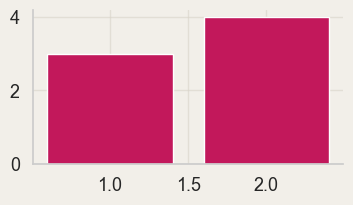

In [21]:
fig, ax = plt.subplots(figsize=(4, 2))
ax.bar([1, 2], [3, 4], color=FEMALE)
plt.savefig('cream_test.png')
plt.show()

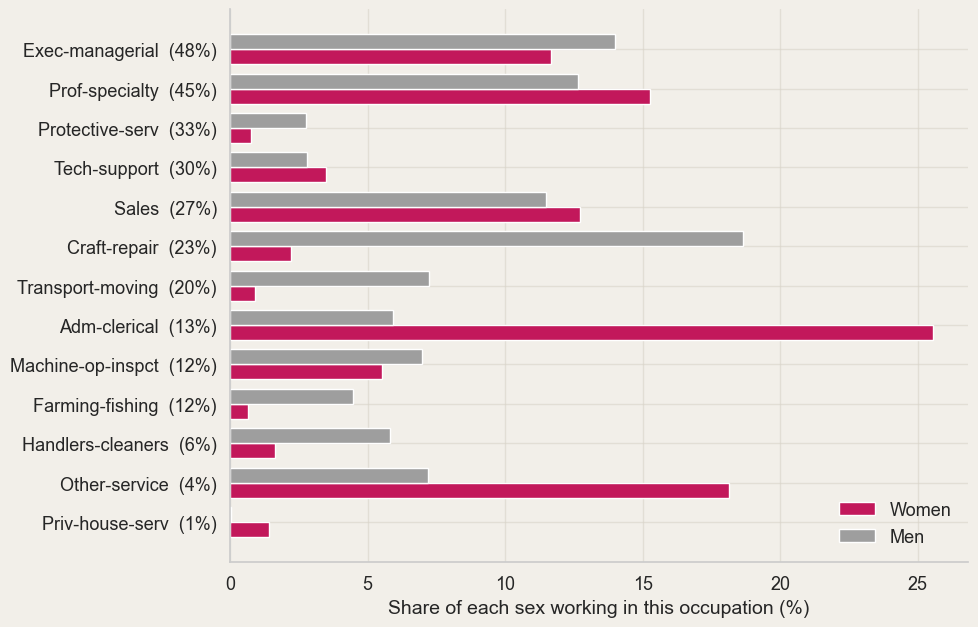

In [22]:
# Occupational composition by sex, sorted by the occupation's >50K rate.
# Sorting by pay rather than alphabetically makes the pattern visible:
# if women concentrate at the bottom, that is the finding.
# Armed-Forces excluded (n=9, too few to plot).
# Title and subtitle are set on the slide, not in the figure.
occ = df.dropna(subset=['occupation'])
occ = occ[occ['occupation'] != 'Armed-Forces']
comp = pd.crosstab(occ['occupation'], occ['sex'], normalize='columns').mul(100)
rate = occ.groupby('occupation')['high_income'].mean().mul(100)
comp['rate'] = rate
comp = comp.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(comp))
h = 0.38

ax.barh(y + h/2, comp['Female'], height=h, color=FEMALE, label='Women')
ax.barh(y - h/2, comp['Male'],   height=h, color=MALE,   label='Men')

ax.set_yticks(y)
ax.set_yticklabels([f"{i}  ({r:.0f}%)" for i, r in zip(comp.index, comp['rate'])])
ax.invert_yaxis()
ax.set_xlabel('Share of each sex working in this occupation (%)')

# ax.set_title('Women concentrate in the lowest-paying occupations',
#              loc='left', pad=15)
# ax.text(0, 1.02, 'Occupations ordered by share earning >$50K (in parentheses)',
#         transform=ax.transAxes, fontsize=9, color='#555555')

ax.legend(frameon=False, loc='lower right')

#ax.annotate('Adm-clerical, Other-service and\nPriv-house-serv hold 45% of women,\nagainst 13% of men',
            #xy=(10, 9.3), fontsize=13, color=FEMALE, va='top', ha='left')

plt.tight_layout()
plt.savefig('femaleshare_working_in_occupation.png')
plt.show()

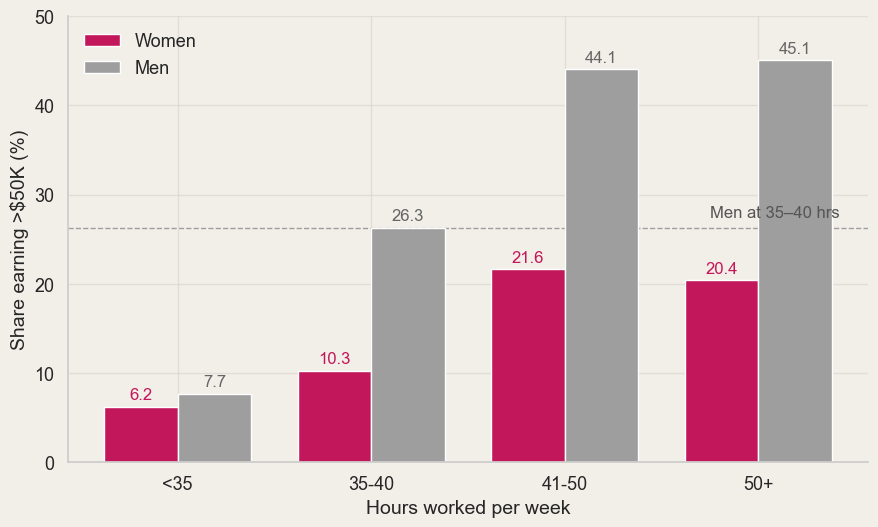

In [23]:
# Return to long hours differs by sex. The reference line marks men working
# 35-40 hours: women working 50+ hours remain below it.
# Title is set on the slide, not in the figure.
hrs = (df.groupby(['hours_band', 'sex'], observed=True)['high_income']
         .mean().unstack().mul(100))

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(hrs))
w = 0.38

ax.bar(x - w/2, hrs['Female'], width=w, color=FEMALE, label='Women')
ax.bar(x + w/2, hrs['Male'],   width=w, color=MALE,   label='Men')

# Reference line: men at 35-40 hours
ref = hrs.loc['35-40', 'Male']
ax.axhline(ref, color=MALE, linestyle='--', linewidth=1, zorder=0)
ax.text(3.42, ref + 1.2, 'Men at 35–40 hrs',
        fontsize=12, color='#555555', ha='right')

# Value labels
for xi, (f, m) in enumerate(zip(hrs['Female'], hrs['Male'])):
    ax.text(xi - w/2, f + 0.8, f'{f:.1f}', ha='center', fontsize=12, color=FEMALE)
    ax.text(xi + w/2, m + 0.8, f'{m:.1f}', ha='center', fontsize=12, color='#666666')

ax.set_xticks(x)
ax.set_xticklabels(hrs.index)
ax.set_xlabel('Hours worked per week')
ax.set_ylabel('Share earning >$50K (%)')
ax.set_ylim(0, 50)
# ax.set_title('Women working 50+ hours remain below men working 35–40',
#              loc='left', pad=15)

ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig('hours_worked_per_week.png')
plt.show()

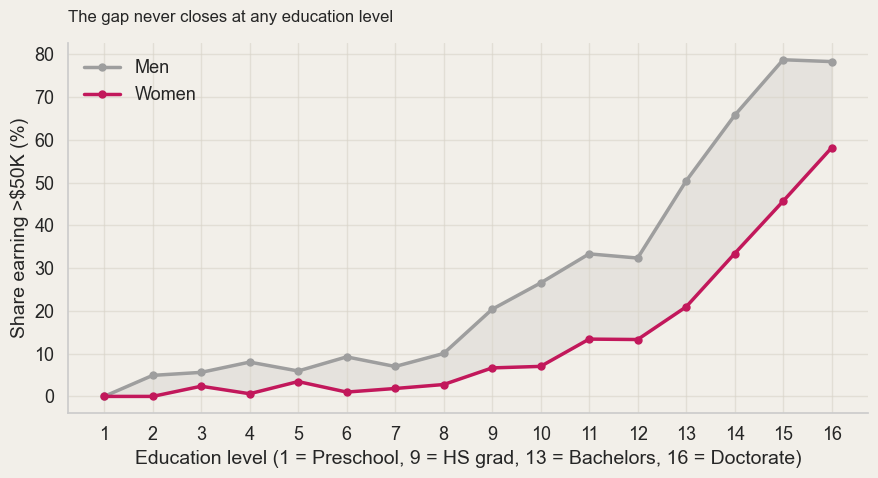

In [24]:
# Gap across all 16 education levels. Lines rather than bars: education-num
# is ordinal, and 16 grouped bar pairs would be unreadable.

ed = (df.groupby(['education-num', 'sex'])['high_income']
        .mean().unstack().mul(100))

fig, ax = plt.subplots(figsize=(9, 5))

# Shade the gap between the two lines
ax.fill_between(ed.index, ed['Female'], ed['Male'],
                color=MALE, alpha=0.15, zorder=0)

ax.plot(ed.index, ed['Male'], color=MALE, linewidth=2.5,
        marker='o', markersize=5, label='Men')
ax.plot(ed.index, ed['Female'], color=FEMALE, linewidth=2.5,
        marker='o', markersize=5, label='Women')

ax.set_xticks(range(1, 17))
ax.set_xlabel('Education level (1 = Preschool, 9 = HS grad, 13 = Bachelors, 16 = Doctorate)')
ax.set_ylabel('Share earning >$50K (%)')
ax.set_title('The gap never closes at any education level',
             loc='left', pad=15)
ax.legend(frameon=False, loc='upper left')
plt.savefig('education_gap.png')
plt.tight_layout()
plt.show()

This chart shows the percentage-point difference, which widens with
education. The ratio moves the opposite direction — from 3.79× at level 10
to 1.35× at level 16. Both are correct: a binary threshold outcome
compresses point differences where base rates are low, so the two metrics
diverge by construction rather than by disagreement.

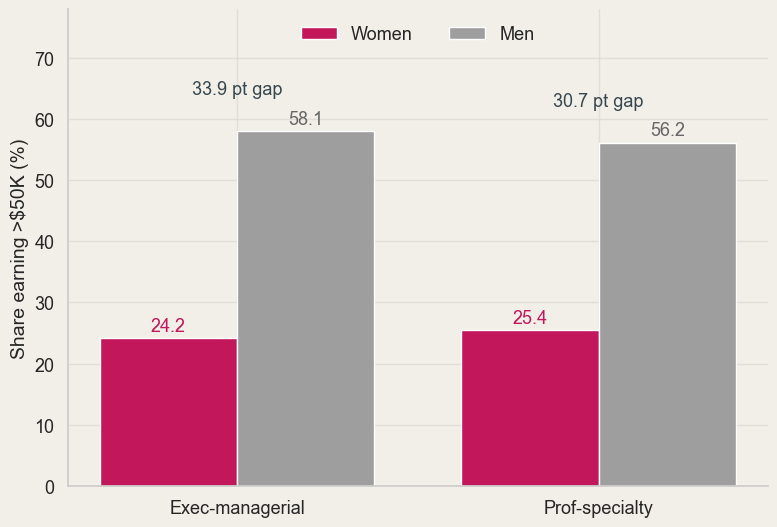

In [25]:
# The gap is largest inside the two highest-paying occupations.
# Title and subtitle are set on the slide, not in the figure.
top = occ[occ['occupation'].isin(['Exec-managerial', 'Prof-specialty'])]
t = top.groupby(['occupation', 'sex'])['high_income'].mean().unstack().mul(100)

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(t))
w = 0.38

ax.bar(x - w/2, t['Female'], width=w, color=FEMALE, label='Women')
ax.bar(x + w/2, t['Male'],   width=w, color=MALE,   label='Men')

for xi, (f, m) in enumerate(zip(t['Female'], t['Male'])):
    ax.text(xi - w/2, f + 1.2, f'{f:.1f}', ha='center', fontsize=13, color=FEMALE)
    ax.text(xi + w/2, m + 1.2, f'{m:.1f}', ha='center', fontsize=13, color='#666666')
    ax.text(xi, max(f, m) + 6, f'{m-f:.1f} pt gap', ha='center',
            fontsize=13, color='#37474F')

ax.set_xticks(x)
ax.set_xticklabels(t.index)
ax.set_ylabel('Share earning >$50K (%)')
ax.set_ylim(0, 78)

# ax.set_title('The gap is widest in the highest-paying occupations',
#              loc='left', pad=15)
# ax.text(0, 1.02, 'Women are 15.3% of Prof-specialty; men 12.6%',
#         transform=ax.transAxes, fontsize=9, color='#555555')

ax.legend(frameon=False, loc='upper center', ncol=2)

plt.tight_layout()
plt.savefig('gap_highest_paying_occupations.png')
plt.show()

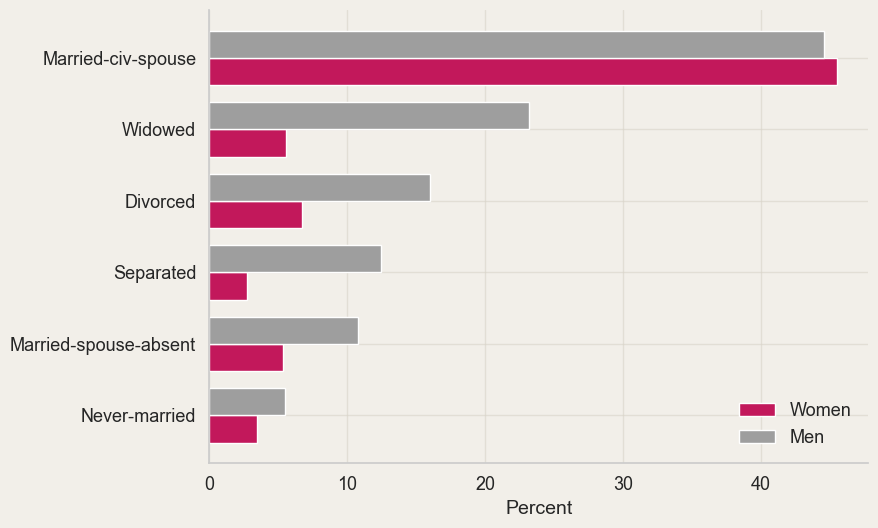

In [26]:
# Marital status: share earning >$50K. The married-civ-spouse row shows no gap.
# Composition (61% of men, 15% of women) goes in the slide subtitle.
# Title is set on the slide, not in the figure.
mar = (df.groupby(['marital-status', 'sex'])['high_income']
         .mean().unstack().mul(100))

# Drop Married-AF-spouse (n=23) and sort by the male rate
keep = [i for i in mar.index if i != 'Married-AF-spouse']
mar = mar.loc[keep]
mar = mar.loc[mar.index[mar['Male'].argsort()[::-1]]]

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(mar)); h = 0.38

ax.barh(y + h/2, mar['Female'], height=h, color=FEMALE, label='Women')
ax.barh(y - h/2, mar['Male'],   height=h, color=MALE,   label='Men')

ax.set_yticks(y)
ax.set_yticklabels(mar.index)
ax.invert_yaxis()
ax.set_xlabel('Percent')
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('marital_rates.png')
plt.show()

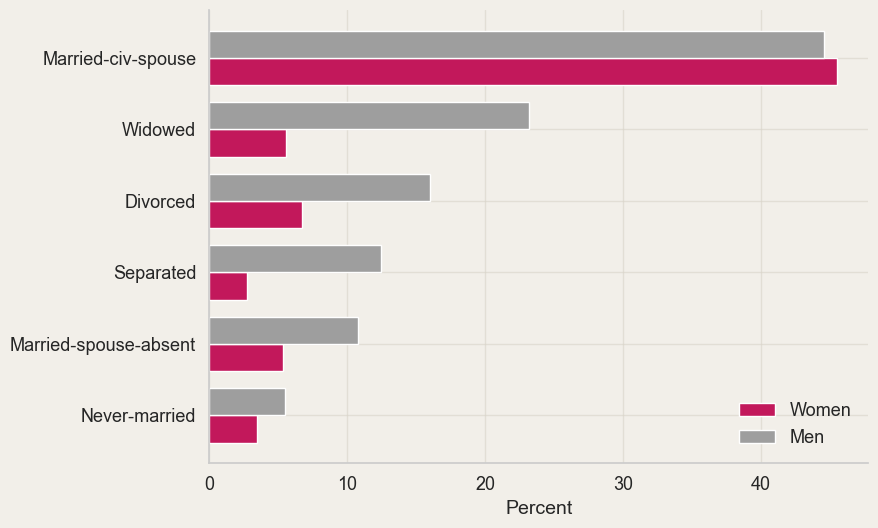

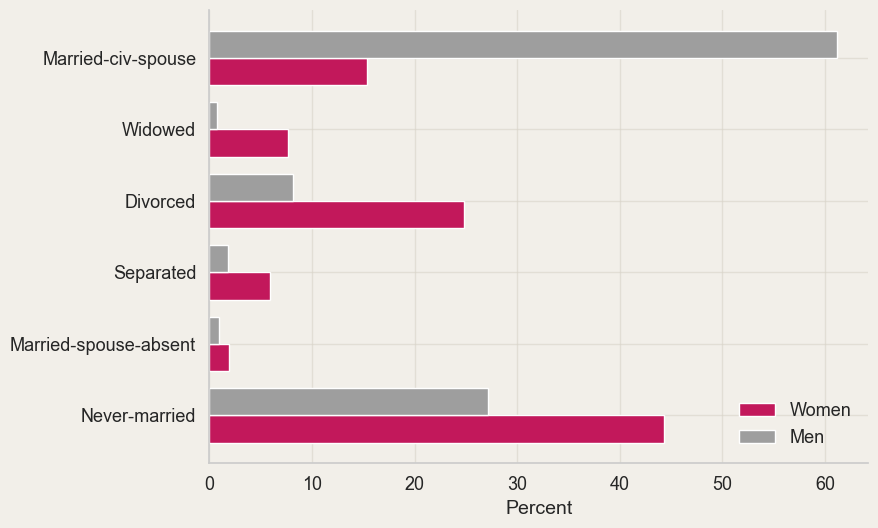

In [27]:
# Two marital-status panels exported separately.
mar = (df.groupby(['marital-status', 'sex'])['high_income']
         .mean().unstack().mul(100))
comp_m = pd.crosstab(df['marital-status'], df['sex'], normalize='columns').mul(100)

# Drop Married-AF-spouse (n=23), sort by male rate, apply same order to both
keep = [i for i in mar.index if i != 'Married-AF-spouse']
mar = mar.loc[keep]
mar = mar.loc[mar.index[mar['Male'].argsort()[::-1]]]
comp_m = comp_m.loc[mar.index]

y = np.arange(len(mar)); h = 0.38

panels = [
    (mar,    'marital_rates.png'),
    (comp_m, 'marital_composition.png'),
]

for data, fname in panels:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(y + h/2, data['Female'], height=h, color=FEMALE, label='Women')
    ax.barh(y - h/2, data['Male'],   height=h, color=MALE,   label='Men')
    ax.set_yticks(y)
    ax.set_yticklabels(data.index)
    ax.invert_yaxis()
    ax.set_xlabel('Percent')
    ax.legend(frameon=False, loc='lower right')
    plt.tight_layout()
    plt.savefig(fname)
    plt.show()

Rather than estimating an adjusted coefficient, the disparity is computed
within matched cells and plotted across strata. This follows directly from
the problem statement. A single adjusted estimate would absorb occupational
sorting into the adjustment and report the residual as the disparity;
plotting the gap within each stratum instead shows where it is located and
how it varies.

Two measures are reported throughout:

- **percentage-point difference** (Male − Female), which captures absolute disadvantage
- **ratio** (Male ÷ Female), which captures relative disadvantage

These diverge systematically. Because income is recorded as a binary
threshold, point differences are mechanically compressed where base rates
are low — a group in which 2% clear $50K cannot show a large point gap
regardless of how unequal the outcome is. Where the two measures point in
different directions, both are reported.

**Strata examined:** education (16 levels), hours worked (4 bands),
occupation (13 categories), and marital status (6 categories).

**Design.** Charts use saturation rather than hue to direct attention:
women are rendered in high-saturation magenta, men in a neutral grey of
similar value. Both remain fully legible; the palette reflects the
analytical focus rather than encoding a value judgment. Chart titles state
the finding rather than describing the axes.

## Report

**Headline.** 30.6% of men exceed $50K against 10.9% of women — a difference
of 19.6 points, or a ratio of 2.79×. Applying the sampling weight (`fnlwgt`)
moves this by 0.3 points and leaves the ratio unchanged.

**The gap does not resolve under matching.**

| Stratum | Result |
|---|---|
| Education | Men exceed women at all 16 levels; no reversals |
| Hours | Gap present in all 4 bands; widens as hours rise |
| Occupation | Present in every occupation with adequate cell sizes |

**Returns to long hours differ.** Moving from 35–40 to 50+ hours raises men
from 26.3% to 45.1% (+18.8 points) and women from 10.3% to 20.4%
(+10.1 points). Women working 50+ hours (20.4%) remain below men working
35–40 (26.3%).

**Occupational sorting is substantial.** 45% of women work in the three
lowest-paying occupations against 13% of men. Craft-repair employs 18.7% of
men and 2.2% of women.

**But sorting does not account for the gap.** The disparity is largest inside
the two highest-paying occupations — 33.9 points in Exec-managerial and 30.8
in Prof-specialty, both exceeding the overall gap of 19.6. Women are
proportionally better represented in Prof-specialty than men (15.3% vs 12.6%)
and still exceed $50K at less than half the male rate.

**One cell shows no gap.** Among married respondents with a spouse present,
rates are 45.5% for women and 44.6% for men. This cell holds 61.1% of men and
15.4% of women, and the dataset covers only people with recorded employment,
so married women appearing here are a selected subset. The parity is more
plausibly selection than equality, but it is reported without adjustment.

## Assessing H1

**H1(a): supported.** The gap persists in every stratum tested. Across all
sixteen education levels men exceed $50K at a higher rate than women, with no
reversals; the same holds across all four hours bands. The disparity does not
resolve under matching.

The two metrics diverge and both are reported. Measured as a point difference
the gap widens with education (2.4 points at level 5 to 33.0 at level 15);
measured as a ratio it narrows (3.79× at level 10 to 1.35× at level 16).
Neither is wrong — the binary threshold compresses point differences where
base rates are low, so the two measures separate by construction.

**H1(b): supported.** Occupational composition differs sharply by sex. 45% of
women work in the three lowest-paying occupations (Adm-clerical,
Other-service, Priv-house-serv) against 13% of men; craft-repair employs
18.7% of men and 2.2% of women. Occupational sorting is a substantial
component of the disparity rather than an explanation of it.

**Unhypothesized finding.** The gap is largest inside the two highest-paying
occupations — 33.9 points in Exec-managerial and 30.8 in Prof-specialty, both
exceeding the overall gap of 19.6. Because women are proportionally better
represented in Prof-specialty than men, this cannot be attributed to women
failing to reach professional occupations. This was not predicted and is
reported as an additional finding rather than as evidence for H1.

**Qualification.** Among married respondents with a spouse present the gap
disappears (45.5% women, 44.6% men). This is the one substantial cell showing
no disparity and is reported without adjustment; the selection argument is
given in the Report section.

## Limitations

**Single cross-section.** 1994 data with no time dimension. Nothing here
speaks to change before or since.

**Binary outcome.** Income is recorded only as above or below $50K, not as an
amount. All results describe the probability of crossing that threshold, and
point differences are compressed where base rates are low.

**Non-random missingness.** The 1,836 records missing employment data show a
smaller sex gap (7.7 points) than complete records (20.1). Excluding them
raises the observed disparity rather than lowering it. All rows are retained;
tables requiring occupation exclude them pairwise and report N.

**Labor-force selection.** The dataset covers people with recorded employment
status, so anyone outside the labor force is absent. In 1994 this omission
was not sex-neutral, and it bears directly on the married-spouse-present cell.

**Excluded variables.** `capital-gain` is topcoded at 99999 (159 records),
inflating its mean from 592 to 1,078 — an 82% distortion from 0.5% of
records. It and `capital-loss` (95.3% zero) are documented but unused.
`relationship` assigns married respondents a category by sex (13,192 Husband
/ 1,566 Wife) and is largely a re-encoding of sex crossed with marital
status; it is not treated as independent. `education` duplicates
`education-num` exactly and is dropped in favor of the ordinal form.

**Thin cells.** Education levels 15 and 16 hold 92 and 86 women;
Armed-Forces holds 9 records and is excluded from occupation charts;
Married-AF-spouse holds 23 and is excluded from the marital chart. These are
reported with counts and not read as precise estimates.

**Correlation, not causation.** Stratified comparison locates the disparity;
it does not identify its cause. Nothing here distinguishes discrimination
from unmeasured differences in experience, tenure, firm, or region.

## Act

**What the analysis supports.** The disparity is not concentrated among
low-education or part-time workers. It is largest among the most credentialed
and the longest-working — precisely the groups where a human-capital
explanation would predict it to be smallest. Interventions targeting
qualifications or hours would not address where the gap is actually located.

**What it does not support.** No causal claim. The analysis locates the
disparity; identifying its mechanism would require longitudinal data, earnings
amounts rather than a threshold, and information on tenure, firm, and career
interruption.

**Next questions.** The married-spouse-present cell is the most informative
open problem: is the observed parity a selection effect, and what would the
comparison look like with the full married population rather than only those
in the labor force? A dataset including non-participants would answer it.

**Reusability.** The cleaning and stratification pipeline is documented and
applies to any binary-outcome dataset with categorical strata. The palette
and chart conventions are defined once and inherited by every figure.

In [28]:
# Recodes: '?' -> NaN across all columns.
# Derived: high_income, is_female, hours_band, emp_missing.
# All rows retained. Charts requiring occupation exclude missing rows
# pairwise; excluded thin cells are noted in each chart's comment.

DERIVED = ['high_income', 'is_female', 'hours_band', 'emp_missing']
DOCUMENTED_UNUSED = ['capital-gain', 'capital-loss', 'fnlwgt',
                     'relationship', 'education']

print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"\nDerived: {DERIVED}")
print(f"Documented but unused: {DOCUMENTED_UNUSED}")
print("\nMissing retained (not dropped):")
print(df.isna().sum()[lambda s: s > 0].to_string())

df.to_csv("adult_income_clean.csv", index=False)
print("\nSaved: adult_income_clean.csv")

Rows: 32,561   Columns: 19

Derived: ['high_income', 'is_female', 'hours_band', 'emp_missing']
Documented but unused: ['capital-gain', 'capital-loss', 'fnlwgt', 'relationship', 'education']

Missing retained (not dropped):
workclass         1836
occupation        1843
native-country     583

Saved: adult_income_clean.csv


In [29]:
#Janna Hoyne


# Micro-Project 3: Classifying Income Above $50K

The target is the dataset's own income label (`<=50K` / `>50K`), modeled with
logistic regression, a decision tree, a random forest, K-nearest neighbours, and
a support vector classifier, and evaluated on accuracy, precision, recall, F1,
and ROC-AUC against a majority-class baseline.

The Acquire, Clean, and Explore work above is carried forward from Project 2
without change, since it was already built around the binary outcome
(`high_income`).

## Problem statement

Project 2 established that the sex gap in the probability of earning above $50K
does not resolve under matching: it persists at all sixteen education levels and
in all four hours bands, and it is widest inside the two highest-paying
occupations (33.9 points in `Exec-managerial`, 30.8 in `Prof-specialty`, against
19.6 overall).

**Hypothesis (H2).** Income class is predictable from these features, and `sex`
remains a non-trivial predictor after conditioning on them. If the descriptive
gap were entirely an artifact of compositional differences, women holding
lower-paying occupations, working fewer hours, holding different credentials,
then conditioning on those variables should drive the `sex` term to
approximately zero. Project 2 predicts it will not.

## Target

The target is `high_income`, already constructed during cleaning as
`income == '>50K'`. It is checked for balance before modeling, because
an imbalanced target makes raw accuracy misleading. A model that predicts the
majority class for every single person scores well on accuracy.

In [30]:
# Target definition and class balance.
mdf = df.dropna(subset=['occupation']).copy()
mdf = mdf[mdf['occupation'] != 'Armed-Forces'] 

y = mdf['high_income'].astype(int)   # 1 = >50K, 0 = <=50K


print(f"Rows retained: {len(mdf):,} of {len(df):,}")
print("\nClass balance:")
print(y.value_counts().rename({0: '<=50K', 1: '>50K'}).to_string())
print(f"\nPositive class: {y.mean():.1%}")
print(f"Majority-class accuracy floor: {max(y.mean(), 1 - y.mean()):.1%}")

Rows retained: 30,709 of 32,561

Class balance:
high_income
<=50K    23060
>50K      7649

Positive class: 24.9%
Majority-class accuracy floor: 75.1%


The positive class is 24.9% of the sample. A model that predicts `<=50K` for
everyone is therefore 75.1% accurate while never identifying a single
high earner. Accuracy alone cannot distinguish that model from a useful one, so
precision, recall, F1, and ROC-AUC are reported alongside it, and
`class_weight='balanced'` is applied where the estimator supports it.

## Features

Features are the characteristics available before the income outcome. Three
exclusions are enforced by the leakage guard below.

| Variable | Status | Reason |
|---|---|---|
| `income` | **Excluded** | The target in string form |
| `high_income` | **Excluded** | The target |
| `pay_index` | **Excluded** | Derived from the target (used descriptively only) |
| `fnlwgt` | Excluded | Census sampling weight, not a personal characteristic |
| `education` | Excluded | Duplicates `education-num` exactly (verified above) |
| `relationship` | Excluded | Largely `sex` × `marital-status` re-encoded |
| `is_female` | Excluded | Duplicates `sex` |
| `occupation` | **Retained** | Legitimate predictor of income; the sorting mechanism is the research question |
| `capital-gain` / `capital-loss` | Recoded | 91.7% / 95.3% zero; enter as presence flags |
| `native-country` | Recoded | 41 sparse levels collapsed to US / non-US |
| `marital-status` | Retained, 7 levels | Collapsing would conceal the Project 2 finding |

With `high_income` as the target, occupation is an ordinary predictor, and
including it is what allows the model to ask whether `sex` matters *beyond*
occupational sorting.

In [31]:
# Engineered features.
mdf['has_capital_gain'] = (mdf['capital-gain'] > 0).astype(int)
mdf['has_capital_loss'] = (mdf['capital-loss'] > 0).astype(int)
mdf['native_us']        = (mdf['native-country'] == 'United-States').astype(int)

NUM = ['age', 'education-num', 'hours-per-week',
       'has_capital_gain', 'has_capital_loss', 'native_us']
CAT = ['sex', 'marital-status', 'race', 'workclass', 'occupation']

X = mdf[NUM + CAT].copy()

print(f"Numeric features    : {len(NUM)}  {NUM}")
print(f"Categorical features: {len(CAT)}  {CAT}")
print(f"\nX shape: {X.shape}   y shape: {y.shape}")

Numeric features    : 6  ['age', 'education-num', 'hours-per-week', 'has_capital_gain', 'has_capital_loss', 'native_us']
Categorical features: 5  ['sex', 'marital-status', 'race', 'workclass', 'occupation']

X shape: (30709, 11)   y shape: (30709,)


In [32]:
# Leakage guard
FORBIDDEN = ['income', 'high_income', 'pay_index', 'is_female', 'fnlwgt']
present = [c for c in FORBIDDEN if c in X.columns]
print("Forbidden columns in X:", present if present else "none")
assert not present, "Leakage: remove these before modeling"

Forbidden columns in X: none


## Train/test split and preprocessing

The split is 75/25 with a fixed seed, **stratified on the target** so the
minority class appears in the same proportion in both halves.

Numeric features are standardized and categorical features one-hot encoded with
the first level dropped. Both transformations are fitted inside a `Pipeline`, so
they are learned from the training fold only and applied to the test fold. No
test information reaches the model during fitting. Scaling is required by KNN
and SVC, which are distance-based, the same preprocessing is applied to every
model so the comparison isolates the estimator.

In [33]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

pre = ColumnTransformer([
    ('num', StandardScaler(), NUM),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT),
])

pre.fit(X_train)
print(f"Train: {X_train.shape[0]:,} rows    Test: {X_test.shape[0]:,} rows")
print(f"Features after encoding: {pre.transform(X_train).shape[1]}")
print(f"\nTrain positive rate: {y_train.mean():.3f}")
print(f"Test positive rate : {y_test.mean():.3f}")

Train: 23,031 rows    Test: 7,678 rows
Features after encoding: 35

Train positive rate: 0.249
Test positive rate : 0.249


## Models

Five classifiers are fitted on identical preprocessing.

| Model | What it does | Why included |
|---|---|---|
| Logistic regression | Models log-odds of the positive class as a linear combination of features | Interpretable baseline; coefficients read as odds ratios |
| Decision tree | Recursive binary splits on single features | Captures interactions a linear model cannot; readable rules |
| Random forest | Averages many decorrelated trees | Usually the strongest of the five; supplies feature importances |
| K-nearest neighbours | Classifies by majority vote of the k closest training points | Fully non-parametric; no assumed functional form |
| Support vector classifier | Finds the maximum-margin separating boundary, RBF kernel | Non-linear decision surface; the classification counterpart|

`class_weight='balanced'` is set where supported, which reweights the classes so
the estimator is not rewarded for ignoring the 24.9% minority. The tree depth is
capped at 8 and the forest's leaves at 5 observations to limit overfitting.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import time

models = {
    'Logistic regression': LogisticRegression(max_iter=2000,
                                              class_weight='balanced'),
    'Decision tree':       DecisionTreeClassifier(max_depth=8, random_state=42,
                                                  class_weight='balanced'),
    'Random forest':       RandomForestClassifier(n_estimators=300,
                                                  min_samples_leaf=5,
                                                  random_state=42, n_jobs=-1,
                                                  class_weight='balanced'),
    'KNN (k=25)':          KNeighborsClassifier(n_neighbors=25),
    'SVC (RBF)':           SVC(kernel='rbf', C=1.0, class_weight='balanced',
                               random_state=42),
}

rows, fitted, scores = [], {}, {}

for name, est in models.items():
    t0 = time.time()
    pipe = Pipeline([('pre', pre), ('model', est)]).fit(X_train, y_train)
    pred = pipe.predict(X_test)

    s = (pipe.predict_proba(X_test)[:, 1] if hasattr(est, 'predict_proba')
         else pipe.decision_function(X_test))

    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall':    round(recall_score(y_test, pred), 3),
        'F1':        round(f1_score(y_test, pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, s), 3),
        'Fit (s)':   round(time.time() - t0, 1),
    })
    fitted[name], scores[name] = pipe, s
    print(f"  fitted {name:22s} ({rows[-1]['Fit (s)']}s)", flush=True)

results = pd.DataFrame(rows)
print("\nTest-set performance\n")
print(results.to_string(index=False))

  fitted Logistic regression    (0.1s)
  fitted Decision tree          (0.1s)
  fitted Random forest          (1.4s)
  fitted KNN (k=25)             (9.2s)
  fitted SVC (RBF)              (12.7s)

Test-set performance

              Model  Accuracy  Precision  Recall    F1  ROC-AUC  Fit (s)
Logistic regression     0.798      0.564   0.831 0.671    0.893      0.1
      Decision tree     0.777      0.532   0.863 0.658    0.877      0.1
      Random forest     0.812      0.586   0.832 0.688    0.903      1.4
         KNN (k=25)     0.840      0.693   0.643 0.667    0.893      9.2
          SVC (RBF)     0.795      0.556   0.864 0.677    0.892     12.7


## Baseline

Classification accuracy has no natural zero point in the way R² does, so a
classifier is fitted explicitly to establish one. With a 24.9% positive class,
75.1% accuracy is what a model that has learned nothing achieves, and every
number in the table above should be read against that figure rather than against
zero.

In [35]:
from sklearn.dummy import DummyClassifier

dummy = Pipeline([('pre', pre),
                  ('model', DummyClassifier(strategy='most_frequent'))]
                ).fit(X_train, y_train)
dp = dummy.predict(X_test)

print("Baseline: predict <=50K for everyone\n")
print(f"  Accuracy : {accuracy_score(y_test, dp):.3f}")
print(f"  Precision: {precision_score(y_test, dp, zero_division=0):.3f}")
print(f"  Recall   : {recall_score(y_test, dp):.3f}")
print(f"  F1       : {f1_score(y_test, dp):.3f}")
print(f"  ROC-AUC  : 0.500 (by definition)")

print(f"\nBest model F1: {results['F1'].max():.3f} "
      f"({results.loc[results['F1'].idxmax(), 'Model']})")
print(f"Baseline F1  : {f1_score(y_test, dp):.3f}")

Baseline: predict <=50K for everyone

  Accuracy : 0.751
  Precision: 0.000
  Recall   : 0.000
  F1       : 0.000
  ROC-AUC  : 0.500 (by definition)

Best model F1: 0.688 (Random forest)
Baseline F1  : 0.000


## Confusion matrix

The metrics table compresses each model to five numbers. The confusion matrix
shows the two error types separately: high earners classified as low
(false negatives) and low earners classified as high (false positives).

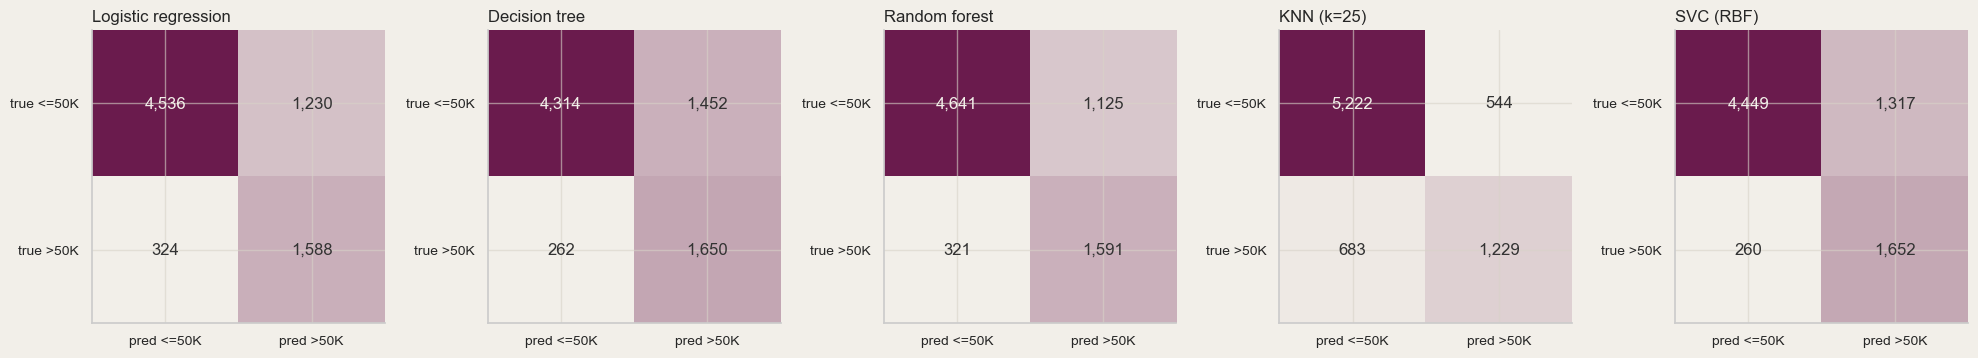

Logistic regression, full report

              precision    recall  f1-score   support

       <=50K      0.933     0.787     0.854      5766
        >50K      0.564     0.831     0.671      1912

    accuracy                          0.798      7678
   macro avg      0.748     0.809     0.763      7678
weighted avg      0.841     0.798     0.808      7678



<Figure size 640x480 with 0 Axes>

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.colors import LinearSegmentedColormap

plum = LinearSegmentedColormap.from_list('plum', [CREAM, '#6A1B4D'])

fig, axes = plt.subplots(1, len(fitted), figsize=(20, 4.2))

for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    im = ax.imshow(cm, cmap=plum)
    ax.set_title(name, fontsize=12, loc='left')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred <=50K', 'pred >50K'],
                                              fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['true <=50K', 'true >50K'],
                                              fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha='center', va='center',
                    fontsize=12,
                    color=CREAM if cm[i, j] > cm.max() * 0.55 else '#333333')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

print("Logistic regression, full report\n")
plt.savefig('logistic_regression.png')
print(classification_report(y_test, fitted['Logistic regression'].predict(X_test),
                            target_names=['<=50K', '>50K'], digits=3))

## ROC curves

Every metric above depends on the 0.5 probability cutoff. The ROC curve traces
performance across all cutoffs, so it separates the quality of a model's
ranking from the choice of threshold.

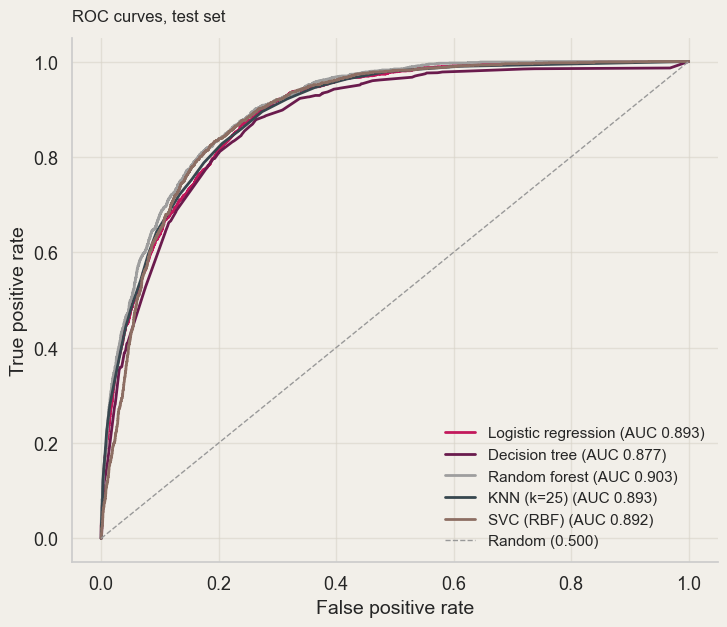

In [37]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7.5, 6.5))
colors = [FEMALE, '#6A1B4D', MALE, '#37474F', '#8D6E63']

for (name, s), c in zip(scores.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f"{name} (AUC {roc_auc_score(y_test, s):.3f})")

ax.plot([0, 1], [0, 1], color='#999999', ls='--', lw=1, label='Random (0.500)')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves, test set', loc='left', pad=12)
ax.legend(frameon=False, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

## Does sex predict income class after conditioning?

Logistic coefficients are on the log-odds scale and are exponentiated into odds
ratios here, where 1.0 means no association once everything else is held
constant. The `sex` coefficient is therefore the conditional association. What
remains after education, age, hours, family structure, race, workclass, and
occupation are all accounted for, which is the quantity the stratified tables in
Micro Project 2 could not produce.

Random forest importances measure each feature's contribution to the splits and
are unsigned, so they establish that a feature matters without establishing
direction. Both are reported because a coefficient that survives conditioning and
a feature that ranks highly under a non-parametric method are different kinds of
evidence for the same claim.

In [38]:
# Logistic coefficients as odds ratios.
log = fitted['Logistic regression']
names = log.named_steps['pre'].get_feature_names_out()
coefs = pd.Series(log.named_steps['model'].coef_[0], index=names)

tab = pd.DataFrame({'coef (log-odds)': coefs.round(3),
                    'odds ratio': np.exp(coefs).round(3)})

print("Largest coefficients\n")
print(tab.reindex(coefs.abs().sort_values(ascending=False).index)
         .head(12).to_string())

print("\n\nThe sex term\n")
print(tab[tab.index.str.contains('sex')].to_string())

Largest coefficients

                                        coef (log-odds)  odds ratio
cat__marital-status_Married-civ-spouse            2.167       8.730
cat__marital-status_Married-AF-spouse             1.999       7.378
cat__occupation_Priv-house-serv                  -1.363       0.256
cat__occupation_Farming-fishing                  -1.058       0.347
cat__workclass_State-gov                         -0.904       0.405
cat__workclass_Self-emp-not-inc                  -0.851       0.427
cat__workclass_Local-gov                         -0.839       0.432
cat__occupation_Handlers-cleaners                -0.754       0.470
num__education-num                                0.748       2.113
cat__occupation_Exec-managerial                   0.738       2.092
cat__occupation_Protective-serv                   0.723       2.061
cat__workclass_Without-pay                       -0.677       0.508


The sex term

               coef (log-odds)  odds ratio
cat__sex_Male            0.219     

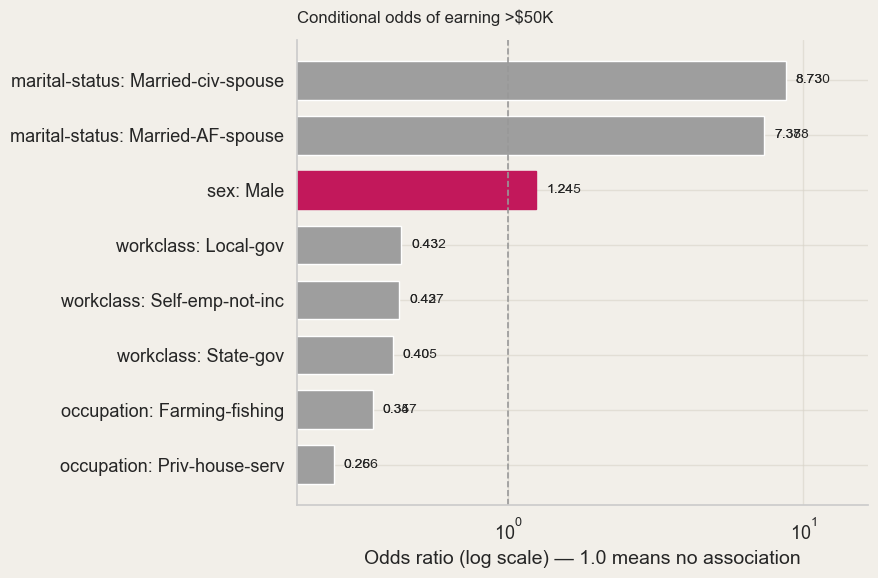

In [39]:
coefs = pd.Series(log.named_steps['model'].coef_[0], index=names)
odds = np.exp(coefs)

sex_key = [i for i in odds.index if 'sex_Male' in i]
top = odds.reindex(coefs.abs().sort_values(ascending=False).index).head(7)
sel = pd.concat([top, odds[sex_key]])
sel = sel[~sel.index.duplicated()].sort_values()

labels = [i.replace('cat__', '').replace('num__', '').replace('_', ': ')
          for i in sel.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(len(sel)), sel.values, color=MALE, height=0.7)

for b, lab in zip(bars, labels):
    if 'sex' in lab:
        b.set_color(FEMALE)

for b, v in zip(bars, sel.values):
    ax.text(v * 1.08, b.get_y() + b.get_height() / 2, f'{v:.3f}',
            va='center', ha='left', fontsize=10)

ax.axvline(1.0, color='#999999', lw=1.2, ls='--')
ax.set_xscale('log')

for b, v in zip(bars, sel.values):
    ax.text(v * 1.08, b.get_y() + b.get_height() / 2, f'{v:.2f}',
            va='center', ha='left', fontsize=10)

ax.set_xlim(sel.values.min() * 0.75, sel.values.max() * 1.9)
ax.set_yticks(range(len(sel)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds ratio (log scale) — 1.0 means no association')
ax.set_title('Conditional odds of earning >$50K', loc='left', pad=12)

plt.tight_layout()
plt.savefig('odds_ratios.png')
plt.show()

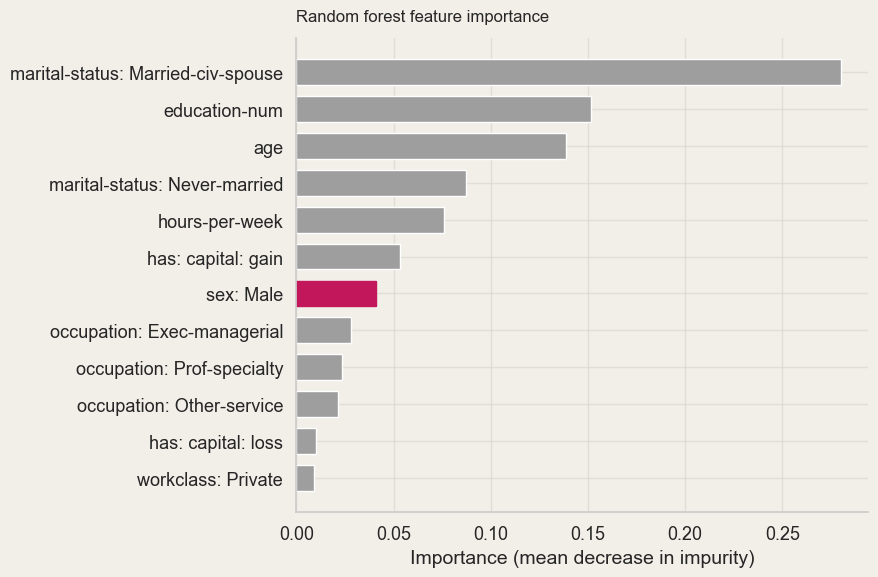

cat__marital-status_Married-civ-spouse    0.2801
num__education-num                        0.1514
num__age                                  0.1387
cat__marital-status_Never-married         0.0875
num__hours-per-week                       0.0758
num__has_capital_gain                     0.0535
cat__sex_Male                             0.0408
cat__occupation_Exec-managerial           0.0279
cat__occupation_Prof-specialty            0.0237
cat__occupation_Other-service             0.0216
num__has_capital_loss                     0.0099
cat__workclass_Private                    0.0091


In [40]:
# Random forest feature importances.
rf = fitted['Random forest']
imp = pd.Series(rf.named_steps['model'].feature_importances_,
                index=names).sort_values(ascending=False).head(12)

labels = [i.replace('cat__', '').replace('num__', '').replace('_', ': ')
          for i in imp.index][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(len(imp)), imp.values[::-1], color=MALE, height=0.7)
# Highlight the sex term
for b, lab in zip(bars, labels):
    if 'sex' in lab:
        b.set_color(FEMALE)

ax.set_yticks(range(len(imp)))
ax.set_yticklabels(labels)
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.set_title('Random forest feature importance', loc='left', pad=12)

plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(imp.round(4).to_string())

## Sex-stratified models

The pooled `sex` coefficient answers one question: **does being female shift the
odds of earning above $50K**, holding everything else constant? It assumes the
relationship between every other feature and income is the same for men and
women.

Fitting the two groups separately relaxes that assumption and tests it. If a
coefficient differs substantially across the two models, the characteristic is
converting into income differently by sex. 

In [41]:
CAT_S = [c for c in CAT if c != 'sex']   # sex is constant inside each subgroup
strat, fit_stats = {}, []

for grp in ['Female', 'Male']:
    itr, ite = X_train['sex'] == grp, X_test['sex'] == grp

    pre_s = ColumnTransformer([
        ('num', StandardScaler(), NUM),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_S),
    ])
    p = Pipeline([('pre', pre_s),
                  ('model', LogisticRegression(max_iter=2000,
                                               class_weight='balanced'))]
                ).fit(X_train.loc[itr, NUM + CAT_S], y_train[itr])

    Xte_g = X_test.loc[ite, NUM + CAT_S]
    strat[grp] = pd.Series(p.named_steps['model'].coef_[0],
                           index=p.named_steps['pre'].get_feature_names_out())
    fit_stats.append({
        'Group': grp,
        'n train': int(itr.sum()),
        'n test': int(ite.sum()),
        'base rate >50K': round(y_train[itr].mean(), 3),
        'Accuracy': round(accuracy_score(y_test[ite], p.predict(Xte_g)), 3),
        'ROC-AUC': round(roc_auc_score(y_test[ite],
                                       p.predict_proba(Xte_g)[:, 1]), 3),
    })

print(pd.DataFrame(fit_stats).to_string(index=False))

comp = pd.DataFrame(strat)
comp['diff (M−F)'] = (comp['Male'] - comp['Female']).round(3)
print("\n\nLargest coefficient differences between the two models\n")
print(comp.reindex(comp['diff (M−F)'].abs().sort_values(ascending=False).index)
          .head(10).round(3).to_string())

 Group  n train  n test  base rate >50K  Accuracy  ROC-AUC
Female     7456    2474           0.113     0.845    0.926
  Male    15575    5204           0.314     0.774    0.870


Largest coefficient differences between the two models

                                        Female   Male  diff (M−F)
cat__marital-status_Married-AF-spouse    2.916  0.609      -2.307
cat__marital-status_Married-civ-spouse   3.416  1.675      -1.741
cat__occupation_Protective-serv          2.017  0.618      -1.399
cat__occupation_Priv-house-serv         -1.354 -0.469       0.885
cat__race_Black                         -0.319  0.558       0.877
cat__occupation_Other-service           -0.178 -0.830      -0.653
cat__occupation_Transport-moving         0.588 -0.058      -0.647
cat__workclass_Self-emp-not-inc         -0.376 -1.023      -0.647
cat__occupation_Farming-fishing         -1.414 -0.916       0.498
cat__race_Other                         -0.345  0.115       0.460


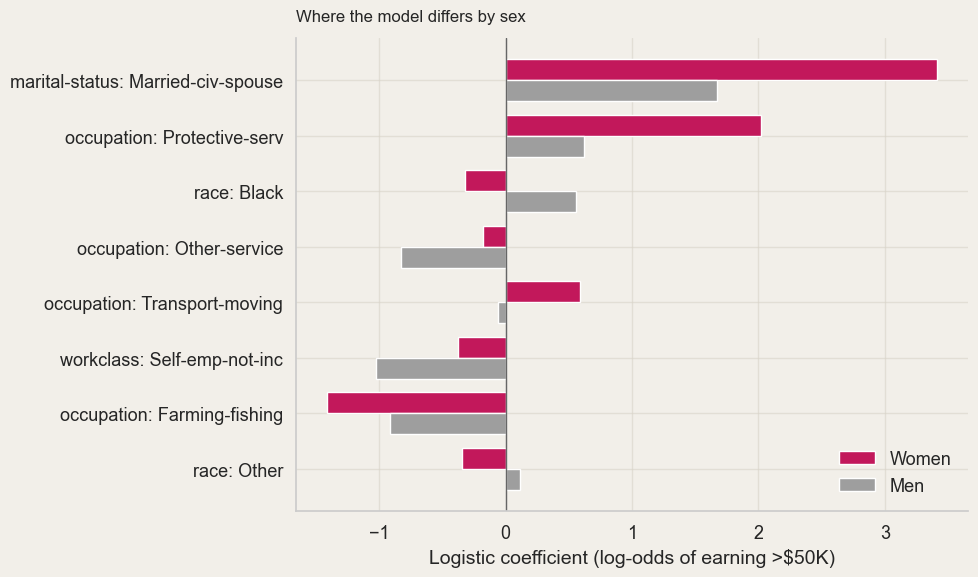

Return to education, by model:
Female        0.829
Male          0.746
diff (M−F)   -0.084


In [42]:
# The comparison plotted, restricted to categories
# Thin cells (Married-AF-spouse, n=23; Without-pay) give unstable coefficients.
THIN = ['Married-AF-spouse', 'Without-pay', 'Never-worked', 'Priv-house-serv']
keep = [i for i in comp.index if not any(t in i for t in THIN)]

top = comp.loc[keep]
top = top.reindex(top['diff (M−F)'].abs()
                     .sort_values(ascending=False).index).head(8).iloc[::-1]

labels = [i.replace('cat__', '').replace('num__', '').replace('_', ': ')
          for i in top.index]
y_pos = np.arange(len(top)); h = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y_pos + h/2, top['Female'], height=h, color=FEMALE, label='Women')
ax.barh(y_pos - h/2, top['Male'],   height=h, color=MALE,   label='Men')
ax.axvline(0, color='#666666', lw=1)

ax.set_yticks(y_pos); ax.set_yticklabels(labels)
ax.set_xlabel('Logistic coefficient (log-odds of earning >$50K)')
ax.set_title('Where the model differs by sex', loc='left', pad=12)
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('stratified_coefficients.png')
plt.show()

print("Return to education, by model:")
print(comp.loc['num__education-num'].round(3).to_string())

## Report

**Every model beats the baseline, and the margin is in F1, not accuracy.**
A classifier predicting `<=50K` for everyone scores 75.1% accuracy with an F1
of 0.000, it identifies no high earners at all. The fitted models reach
0.78–0.84 accuracy, which looks like a modest gain, but F1 moves from 0.000 to
roughly 0.66–0.69 and ROC-AUC from 0.500 to 0.88–0.90. The accuracy column
understates the improvement because the baseline is already 75% correct by
construction.

**Random forest performs best overall** (F1 ≈ 0.69, ROC-AUC ≈ 0.90). It captures interactions between features that the
linear model must be told about explicitly. Logistic regression is close behind
(ROC-AUC ≈ 0.89) at a fraction of the fitting cost, and it is the only model of
the five whose parameters read directly as an effect size.

**The precision/recall trade-off differs sharply by model.** With
`class_weight='balanced'`, logistic regression, the decision tree, and SVC reach
recall of 0.83–0.86 at precision near 0.55. They find most high earners while
misclassifying many low earners. Unweighted KNN inverts this, with precision
0.69 and recall 0.64. the ranking depends on
whether missing a high earner or falsely flagging one is the error.

**Sex remains predictive after conditioning.** In the pooled
logistic model the male coefficient is +0.22 log-odds, an odds ratio of about
1.25. Men's odds of earning above $50K are roughly 25% higher than women's
after education, age, hours worked, marital status, race, workclass, and
occupation are all held constant. In the random forest, `sex` ranks seventh of
35 encoded features. Marital status dominates both models by a wide margin
(`Married-civ-spouse`, odds ratio ≈ 8.7).

**The sex-stratified models fit women's outcomes better than men's**
(ROC-AUC 0.93 vs 0.87), and the coefficients diverge substantially. The largest
gaps are in marital status, `Married-civ-spouse` carries roughly twice the
coefficient in the women's model as in the men's.
The return to education is close to equal (0.83 for women, 0.75 for men, on the
standardized scale).

## Assessing H2

**Predictability: supported.** All five classifiers substantially outperform the
majority-class baseline on every metric that is not degenerate under imbalance.
ROC-AUC near 0.90 indicates the models rank a randomly chosen high earner above
a randomly chosen low earner about 90% of the time.

**Sex as a predictor after conditioning: supported, with a qualification the
descriptive analysis could not have supplied.** The `sex` term survives
conditioning on occupation, education, hours, and family structure at an odds
ratio of about 1.25.

Conditioning on marital status shrinks the sex coefficient, but
MicroProject 2 showed that the married-spouse-present cell contains 61.1% of men and
15.4% of women and that women in it are a labor-force-selected subset. A
variable that is itself distributed unequally by sex, and selected on, is not a
neutral control. The shrinkage is therefore evidence about where the
disparity is encoded. The stratified models make the same point from the other direction: marriage
carries a substantially different coefficient for women than for men, so it is
not operating as a common background characteristic.

**What would falsify this.** If the `sex` coefficient had gone to approximately
zero and the stratified models had produced near-identical coefficients, the
descriptive gap would be explicable as composition. Neither occurred.

## Techniques used and why

**Logistic regression.** Models the log-odds of the positive class as a linear combination of the features, mapped through the logistic function to a probability between 0 and 1. It is the only model of the five whose parameters carry a direct interpretation, since exponentiated coefficients are odds ratios, which is why it supplies the effect estimate for the hypothesis. It assumes effects are additive in log-odds, and the stratified fits test that assumption directly.

**Decision tree.** Splits the data recursively on one feature at a time, choosing each split to maximise class purity in the resulting branches. It captures interactions without being told they exist and produces rules that can be read directly, but it overfits when grown without limit, so depth is capped at 8.

**Random forest.** Averages 300 trees, each grown on a bootstrap sample of the rows with a random subset of features available at each split. Decorrelating the trees this way reduces the variance that makes a single tree unstable, and it is the strongest performer here. The cost is interpretability: importances establish that a feature matters without establishing in which direction.

**K-nearest neighbours.** Classifies each case by majority vote among the 25 closest training points, assuming no functional form at all. That makes it a check on the parametric models, since a method that assumes nothing and finds no more structure than logistic regression indicates the linear specification is not leaving much unused. It is distance-based, so the pipeline's scaling is required rather than optional, and smaller values of k overfit at this sample size.

**Support vector classifier (RBF kernel).** Finds the boundary that separates the classes with the widest margin, with the kernel mapping the features into a higher-dimensional space so that a flat separator there corresponds to a curved one in the original features. It tests whether the income boundary is meaningfully non-linear, and like KNN it depends on distances and requires scaling.

**Why `class_weight='balanced`** With 24.9% positive cases an unweighted estimator can lower its loss by favouring the majority class, so the classes are reweighted inversely to their frequency, which raises recall at some cost to precision. 

**Why stratified splitting.** Splitting an imbalanced target at random can allocate the minority class unevenly between train and test, which would make the test metrics partly an artifact of the split. Stratification holds the class proportion fixed in both halves.

## Limitations

**Single cross-section.** 1994 data with no time dimension.

**Binary outcome.** Income is recorded only as above or below 50K, not as an
amount. Every result describes the probability of crossing a threshold, and a
model cannot distinguish someone at $51,000 from someone at 500,000.

**Class imbalance.** The 24.9% positive rate means accuracy is a weak metric and
the balanced class weighting is doing the work in the results. A different
weighting choice would move the precision/recall balance and, with it, the
apparent ranking of the models.

**Non-random missingness.** Records missing employment data show a smaller sex
gap (7.7 points) than complete records (20.1). Rows missing `occupation` are
dropped for modeling because occupation is a feature, so the modeling sample is
the higher-gap subset.

**Labor-force selection.** The dataset covers people with recorded employment,
so anyone outside the labor force is absent. In 1994 this omission was not
sex-neutral, and it bears directly on the married-spouse-present cell that
dominates both models.

**Controls that are not neutral.** Conditioning on occupation, hours, and
marital status shrinks the `sex` coefficient. Each of those variables is itself
distributed unequally by sex. The shrinkage locates the disparity; it does not
dissolve it.

**No hyperparameter search.** Tree depth, forest size, k, and C are set to
defensible values rather than tuned by cross-validated grid search. A tuned
comparison could reorder the models, though the gaps between them are large
relative to the likely tuning gains.

## Act

**What the analysis supports.** Income class above $50K is predictable at
ROC-AUC ≈ 0.90 from characteristics available before the outcome. Sex carries
residual predictive weight after conditioning on occupation, education, hours,
and family structure — the disparity is not purely compositional. But marital
status, not occupation, absorbs most of the descriptive gap, and it does so
while carrying a substantially different coefficient for women than for men.

In [43]:
#Janna Hoyne